# Champion Stack + Upgraded SVC — Targeted Submission (`champion_better_svc_submission.ipynb`)

**Self-contained.** This notebook does **not** modify `hack2.ipynb`. It builds one specific model,
trains it on all data, and writes a submission — with a careful file-safety protocol so the
existing `submission.csv` is backed up and only replaced if every check passes.

## What we're building, and why exactly this

The champion stack, with **one** change: the SVC member uses the config the *wider* search found —
**`SVC(kernel="rbf", C=20, gamma=0.01, probability=True)`**. CatBoost and XGBoost stay at their
champion defaults. Meta = `LogisticRegression`, internal `cv=5`, `stack_method="predict_proba"`.

**Why only the SVC change (not the full tuned stack):**
- The wider-tuning experiment showed the **fully** tuned stack *ties* the champion (0.8345 vs
  0.8308 — inside the noise band) **and is noisier** (fold std 0.0091 vs 0.0052). Higher variance
  is *worse* for leaderboard transfer: a noisier CV estimate is a less reliable predictor of the
  held-out score.
- But the **SVC upgrade alone** is where the mechanism lives: it moved the stage-2/3 bottleneck the
  most (confusion 8.7% → 8.0%, stage-2 F1 0.781 → 0.787), and it's concentrated in the **curved**
  member that demonstrably broke the ceiling back in Part 8. So this isolates the *one* change with
  a real, explainable reason behind it, instead of importing the extra variance from re-tuning the
  two tree models for no clear gain.

**Honest expectation:** roughly a coin-leaning-no — about **40%** chance it's a small *real* gain
(~0.834), otherwise it lands as noise around the champion's **0.8328**. We can't settle a
within-noise question from CV alone, so we're submitting to **see** on the leaderboard.

## Facts (reused, not re-derived)
- `train.csv` (9,000; fallback `tran.csv`), `final-check.csv` (5,000; `id` + 21 features incl.
  `eog_burst_index` ~50% missing). Target `sleep_stage` (4 classes). Metric **macro-F1**.
- `id` is a row index → **drop** from features, **keep** for the submission.
- Features = 21 + `eog_burst_index_missing` flag (from raw NaNs, *before* imputation). The test
  frame is built **identically**.
- Folds: `StratifiedKFold(5, shuffle=True, random_state=42)`.

## 1. Setup + immediate backup of the existing submission

Before doing anything else, we **back up** the current `submission.csv` (if present) to
`submission_champion_backup.csv`. That way, whatever happens below, the previously-uploaded file
is recoverable. We only ever overwrite `submission.csv` at the very end, and only if all sanity
checks pass.

In [1]:
# Installs if needed:
# %pip install catboost xgboost
import os, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

# --- File-safety step 1: back up the current submission.csv immediately. ---
if os.path.exists("submission.csv"):
    shutil.copyfile("submission.csv", "submission_champion_backup.csv")
    print("Backed up existing submission.csv -> submission_champion_backup.csv")
else:
    print("No existing submission.csv found; nothing to back up.")

Backed up existing submission.csv -> submission_champion_backup.csv


In [2]:
def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None found: {candidates}")

train_df, train_file = _load_first_existing(["train.csv", "tran.csv"])
test_df,  test_file  = _load_first_existing(["final-check.csv"])

ID_COLS = [c for c in ["id"] if c in train_df.columns]
base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
X = train_df[base_features].copy()
y = train_df[TARGET].copy()
X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)     # flag from RAW NaNs, before imputing
model_features = base_features + [FLAG_COL]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classes = sorted(y.unique())
print(f"train={train_file} {X.shape} | test={test_file} {test_df.shape} | features={len(model_features)}")

def make_pipeline(model):
    # SVC needs scale; CatBoost/XGBoost ignore it (harmless) -> one uniform per-member pipeline.
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale",  StandardScaler()),
                     ("model",  model)])

# --- Base members: CatBoost/XGBoost at champion DEFAULTS; SVC UPGRADED (C=20, gamma=0.01). ---
def f_cat():  return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                   random_state=RANDOM_STATE, verbose=0, allow_writing_files=False))
def f_xgb():  return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                                   subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
                                   eval_metric="mlogloss", n_jobs=-1, tree_method="hist"))
def f_svc():  return make_pipeline(SVC(kernel="rbf", C=20, gamma=0.01, probability=True,
                                       random_state=RANDOM_STATE))

def build_stack():
    return StackingClassifier(
        estimators=[("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", f_svc())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

print("Model: champion stack with SVC(C=20, gamma=0.01); CatBoost/XGBoost at defaults.")

train=train.csv (9000, 22) | test=final-check.csv (5000, 22) | features=22
Model: champion stack with SVC(C=20, gamma=0.01); CatBoost/XGBoost at defaults.


## 2. Re-confirm this stack's CV macro-F1

We run this exact stack through the same 5 folds and compare to:
- the **champion** (0.8308 ± 0.0052), and
- the **fully tuned** stack (0.8345 ± 0.0091, noisier).

We expect this to sit **between** them and likely **tie** the champion within noise — that's fine.
The point of this notebook is to get a *leaderboard* read on the one change with a real mechanism;
CV alone cannot resolve a within-noise difference.

> Slow cell: the stack fits SVC many times via its internal CV. Let it run.

In [3]:
Xv = X[model_features]
fold_scores, oof = [], np.empty(len(Xv), dtype=int)
t0 = time.time()
for tr, va in cv.split(Xv, y):
    s = build_stack(); s.fit(Xv.iloc[tr], y.iloc[tr])
    oof[va] = np.asarray(s.predict(Xv.iloc[va])).ravel().astype(int)
    fold_scores.append(f1_score(y.iloc[va], oof[va], average="macro"))
cv_mean, cv_std = float(np.mean(fold_scores)), float(np.std(fold_scores))
stage2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
print(f"This stack CV macro-F1 = {cv_mean:.4f} +/- {cv_std:.4f}   stage2-F1 = {stage2:.4f}  "
      f"({time.time()-t0:.0f}s)")
print(f"Per-fold: {[f'{s:.3f}' for s in fold_scores]}")
print(f"\nReference: champion 0.8308 +/- 0.0052 | full-tuned 0.8345 +/- 0.0091")
print(f"Delta vs champion: {cv_mean-0.8308:+.4f}  -> "
      f"{'within noise (tie) — checking leaderboard' if abs(cv_mean-0.8308) <= 0.0052 else 'outside noise'}")

This stack CV macro-F1 = 0.8330 +/- 0.0071   stage2-F1 = 0.7844  (68s)
Per-fold: ['0.835', '0.819', '0.838', '0.837', '0.837']

Reference: champion 0.8308 +/- 0.0052 | full-tuned 0.8345 +/- 0.0091
Delta vs champion: +0.0022  -> within noise (tie) — checking leaderboard


## 3. Build the test feature frame (assert exact column match)

Prepare `final-check.csv` exactly like training: save `id`, drop it from features, add the
`eog_burst_index_missing` flag from raw NaNs, and reorder to match `X`'s columns. We **assert**
the columns match by name and order — a mismatch is the classic silent submission bug.

In [4]:
assert "id" in test_df.columns, "final-check.csv must contain an 'id' column!"
test_ids = test_df["id"].copy()                                   # keep for submission

X_test = test_df.drop(columns=["id"]).copy()
X_test[FLAG_COL] = X_test["eog_burst_index"].isna().astype(int)   # same flag rule as train
X_test = X_test[model_features]                                    # reorder to match exactly

same_cols = list(X_test.columns) == list(model_features)
print(f"[{'PASS' if same_cols else 'FAIL'}] test feature columns match train (name + order)")
assert same_cols, "Test/train feature columns differ — stop before submitting."
print(f"X_test: {X_test.shape} | eog_burst_index missing in test: {X_test[FLAG_COL].mean()*100:.1f}%")

[PASS] test feature columns match train (name + order)
X_test: (5000, 22) | eog_burst_index missing in test: 49.5%


## 4. Train on ALL training data

CV was for *evaluation*; the model is already chosen. We now refit on **100%** of the labeled rows
for the strongest fit (more data → better model). This stays leakage-free: with no validation fold
left, fitting impute/scale on all of `X` is correct, and the fitted stack is only **applied** to
the test set (`.predict`), never `.fit` on test. Stacking's internal `cv=5` keeps its meta-features
out-of-fold.

> Slowest cell: one full stack fit (all bases + SVC several times via the internal CV). Let it run.

In [5]:
t0 = time.time()
final_model = build_stack()
final_model.fit(X[model_features], y)
print(f"Final stack trained on all {len(X)} rows in {time.time()-t0:.0f}s.")
print("Base members:", [n for n, _ in final_model.estimators])

Final stack trained on all 9000 rows in 16s.
Base members: ['catboost', 'xgboost', 'svc_rbf']


## 5. Predict → `submission_better_svc.csv`

Predict integer labels for the test set and write the new submission to **`submission_better_svc.csv`
first** — `submission.csv` stays untouched until the sanity checks pass. Format mirrors the
competition's two columns (`id, sleep_stage`).

In [6]:
test_pred = np.asarray(final_model.predict(X_test)).ravel().astype(int)

sample_cols = ["id", TARGET]
for s in ["sample_submission.csv", "submission.csv", "submission_champion_backup.csv"]:
    if os.path.exists(s):
        sample_cols = list(pd.read_csv(s, nrows=1).columns)
        print(f"Mirroring columns from '{s}': {sample_cols}")
        break
else:
    print(f"No sample file found; using default columns: {sample_cols}")

submission = pd.DataFrame({sample_cols[0]: test_ids.values, sample_cols[1]: test_pred})[sample_cols]
NEW_FILE = "submission_better_svc.csv"
submission.to_csv(NEW_FILE, index=False)
print(f"\nWrote {NEW_FILE} {submission.shape} (submission.csv still untouched).")

Mirroring columns from 'submission.csv': ['id', 'sleep_stage']

Wrote submission_better_svc.csv (5000, 2) (submission.csv still untouched).


## 6. Sanity checks (gate before overwriting submission.csv)

Each prints PASS/FAIL. Only if **all** pass do we promote this file to `submission.csv`.

[PASS] row count == 5000: 5000
[PASS] zero NaN predictions: 0 missing
[PASS] integer labels in {0,1,2,3}: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Class distribution (train vs predicted):
             train_%  pred_%
sleep_stage                 
0               22.2    22.3
1               27.1    25.5
2               24.9    26.2
3               25.8    26.0
[PASS] every class >= 5%: all present
[PASS] columns == ['id', 'sleep_stage']: ['id', 'sleep_stage']


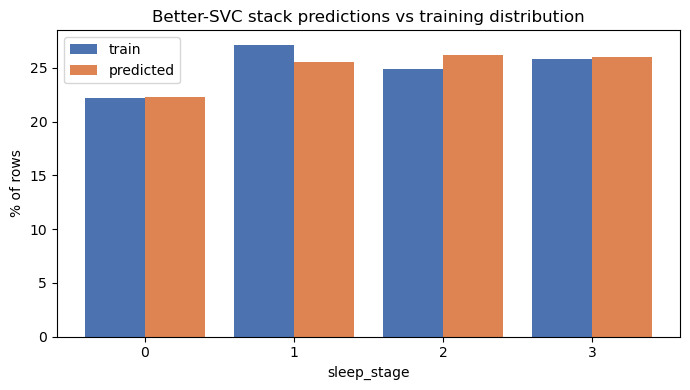


submission.head():
  id  sleep_stage
9000            0
9001            3
9002            1
9003            2
9004            3

ALL CHECKS PASSED


In [7]:
ok = True
col_pred = sample_cols[1]

c1 = len(submission) == len(test_df);                              ok &= c1
print(f"[{'PASS' if c1 else 'FAIL'}] row count == 5000: {len(submission)}")

c2 = int(submission[col_pred].isna().sum()) == 0;                  ok &= c2
print(f"[{'PASS' if c2 else 'FAIL'}] zero NaN predictions: {int(submission[col_pred].isna().sum())} missing")

c3 = submission[col_pred].dropna().apply(lambda v: float(v).is_integer()).all() \
     and set(submission[col_pred].unique()).issubset({0,1,2,3});  ok &= c3
print(f"[{'PASS' if c3 else 'FAIL'}] integer labels in {{0,1,2,3}}: {sorted(submission[col_pred].unique())}")

pred_dist  = submission[col_pred].value_counts(normalize=True).sort_index()
train_dist = y.value_counts(normalize=True).sort_index()
print("\nClass distribution (train vs predicted):")
print(pd.DataFrame({"train_%": (train_dist*100).round(1),
                    "pred_%":  (pred_dist.reindex(train_dist.index).fillna(0)*100).round(1)}))
near_absent = pred_dist[pred_dist < 0.05]
c4 = near_absent.empty;                                            ok &= c4
print(f"[{'PASS' if c4 else 'FAIL'}] every class >= 5%: "
      f"{'all present' if c4 else 'near-absent ' + str(near_absent.index.tolist())}")

c5 = list(submission.columns) == sample_cols;                      ok &= c5
print(f"[{'PASS' if c5 else 'FAIL'}] columns == {sample_cols}: {list(submission.columns)}")

fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(train_dist))
ax.bar(xs-0.2, train_dist.values*100, width=0.4, label="train", color="#4c72b0")
ax.bar(xs+0.2, pred_dist.reindex(train_dist.index).fillna(0).values*100, width=0.4,
       label="predicted", color="#dd8452")
ax.set_xticks(xs); ax.set_xticklabels(train_dist.index)
ax.set_xlabel("sleep_stage"); ax.set_ylabel("% of rows")
ax.set_title("Better-SVC stack predictions vs training distribution"); ax.legend()
plt.tight_layout(); plt.show()

print("\nsubmission.head():"); print(submission.head().to_string(index=False))
print(f"\n{'ALL CHECKS PASSED' if ok else 'SOME CHECKS FAILED - submission.csv will NOT be changed'}")

## 7. Promote to `submission.csv` (only if all checks passed)

If every check passed, copy `submission_better_svc.csv` over `submission.csv` (the upload file).
The previous version is safe in `submission_champion_backup.csv`. If any check failed, we leave
`submission.csv` exactly as it was.

In [8]:
if ok:
    shutil.copyfile(NEW_FILE, "submission.csv")
    print("All checks passed -> submission.csv UPDATED with the better-SVC stack.")
    print("Previous submission is preserved in submission_champion_backup.csv.")
    chk = pd.read_csv("submission.csv")
    print(f"submission.csv now: {chk.shape}, columns {list(chk.columns)}")
    print(chk.head(3).to_string(index=False))
else:
    print("Sanity checks FAILED -> submission.csv left UNCHANGED. "
          "Inspect submission_better_svc.csv before promoting.")

All checks passed -> submission.csv UPDATED with the better-SVC stack.
Previous submission is preserved in submission_champion_backup.csv.
submission.csv now: (5000, 2), columns ['id', 'sleep_stage']
  id  sleep_stage
9000            0
9001            3
9002            1


## 8. Done

**Final model:** champion stacking ensemble — base **[CatBoost(default), XGBoost(default),
SVC-RBF(C=20, gamma=0.01)]**, meta **LogisticRegression** (internal `cv=5`, `predict_proba`) —
trained on all 9,000 labeled rows in leakage-free per-member pipelines.

**CV macro-F1:** see Part 2 above (expected to tie the champion's 0.8308 within noise; we're
submitting to get the leaderboard read on the one mechanistically-motivated change).

**Files written:**
- `submission_champion_backup.csv` — the previous `submission.csv`, preserved.
- `submission_better_svc.csv` — the new predictions.
- `submission.csv` — updated to the better-SVC stack **only after all sanity checks passed**.

> Reminder: before uploading, verify the exact submission format on the competition page (column
> names, header, id order). A format mismatch is the most common reason a correct model scores zero.